# Retail Sales Performance & Business Intelligence Dashboard
## IBM SkillsBuild Data Analytics with AI Internship — Final Project

**Dataset:** Sample - Superstore (2014–2017)  
**Framework:** KPI → TREND → DRIVER → RISK → ACTION  
**Note:** All metrics are computed directly from the dataset. No values are hardcoded or estimated.

---
## Section 1 — Setup & Data Load

In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_csv('Sample - Superstore.csv', parse_dates=['Order Date', 'Ship Date'], encoding='latin-1')

# Derive time columns
df['Year']      = df['Order Date'].dt.year
df['Month']     = df['Order Date'].dt.month
df['YearMonth'] = df['Order Date'].dt.to_period('M').astype(str)

print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Dataset shape: (9994, 24)
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit', 'Year', 'Month', 'YearMonth']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,YearMonth
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,2015-10


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [3]:
df[['Sales', 'Quantity', 'Discount', 'Profit']].describe().round(2)

,Sales,Quantity,Discount,Profit
count,9994.00,9994.00,9994.00,9994.00
mean,229.86,3.79,0.16,28.66
std,623.25,2.23,0.21,234.26
min,0.44,1.00,0.00,-6599.98
25%,17.28,2.00,0.00,1.73
50%,54.49,3.00,0.20,8.67
75%,209.94,5.00,0.20,29.36
max,22638.48,14.00,0.80,8399.98


---
## Section 2 — Data Quality Check

In [4]:
print('=== Missing Values ===')
print(df.isnull().sum())
print()
print('=== Duplicate Rows ===')
print('Duplicate rows:', df.duplicated().sum())
print()
print('=== Date Range ===')
print('Earliest order:', df['Order Date'].min().date())
print('Latest order:  ', df['Order Date'].max().date())
print()
print('=== Negative Profit Rows ===')
neg = df[df['Profit'] < 0]
print(f'{len(neg):,} rows ({len(neg)/len(df)*100:.1f}%) have negative profit')
print()
print('=== Unique values ===')
for col in ['Segment', 'Category', 'Region', 'Ship Mode']:
    print(f'  {col}: {sorted(df[col].unique().tolist())}')

=== Missing Values ===
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
YearMonth        0
dtype: int64

=== Duplicate Rows ===
Duplicate rows: 0

=== Date Range ===
Earliest order: 2014-01-03
Latest order:   2017-12-30

=== Negative Profit Rows ===
1,871 rows (18.7%) have negative profit

=== Unique values ===
  Segment: ['Consumer', 'Corporate', 'Home Office']
  Category: ['Furniture', 'Office Supplies', 'Technology']
  Region: ['Central', 'East', 'South', 'West']
  Ship Mode: ['First Class', 'Same Day', 'Second Class', 'Standard Class']


**Data quality summary:**  
The dataset contains 9,994 rows and 21 columns spanning January 2014 to December 2017.  
No missing values were detected in the key analytical columns (Sales, Profit, Discount). A meaningful proportion of rows (~`len(neg)/len(df)*100`%) carry negative profit — these are not data errors but reflect real loss-making transactions driven by discounting and product costs.

---
## Section 3 — Executive KPIs

In [5]:
total_revenue    = df['Sales'].sum()
total_profit     = df['Profit'].sum()
profit_margin    = total_profit / total_revenue * 100
total_orders     = df['Order ID'].nunique()
total_customers  = df['Customer ID'].nunique()
avg_order_value  = total_revenue / total_orders

print(f'Total Revenue:       ${total_revenue:>12,.2f}')
print(f'Total Profit:        ${total_profit:>12,.2f}')
print(f'Profit Margin:       {profit_margin:>11.2f}%')
print(f'Total Orders:        {total_orders:>12,}')
print(f'Total Customers:     {total_customers:>12,}')
print(f'Avg Order Value:     ${avg_order_value:>12,.2f}')

Total Revenue:       $2,297,200.86
Total Profit:        $  286,397.02
Profit Margin:             12.47%
Total Orders:               5,009
Total Customers:              793
Avg Order Value:     $      458.61


**Commentary:**  
The business generated over $2.2M in revenue across 5,009 unique orders from 793 customers over four years. The overall profit margin of ~12.5% indicates a moderately profitable operation, though this headline figure masks significant variation by category, region, and product — explored in subsequent sections.

---
## Section 4 — Revenue & Profit Trends (Year-over-Year)

In [6]:
yearly = (
    df.groupby('Year')
    .agg(Revenue=('Sales', 'sum'), Profit=('Profit', 'sum'))
    .reset_index()
)
yearly['ProfitMarginPct'] = yearly['Profit'] / yearly['Revenue'] * 100
yearly['RevenueGrowthPct'] = yearly['Revenue'].pct_change() * 100
print(yearly.round(2).to_string(index=False))

 Year   Revenue   Profit  ProfitMarginPct  RevenueGrowthPct
 2014 484247.50 49543.97            10.23               NaN
 2015 470532.51 61618.60            13.10             -2.83
 2016 609205.60 81795.17            13.43             29.47
 2017 733215.26 93439.27            12.74             20.36


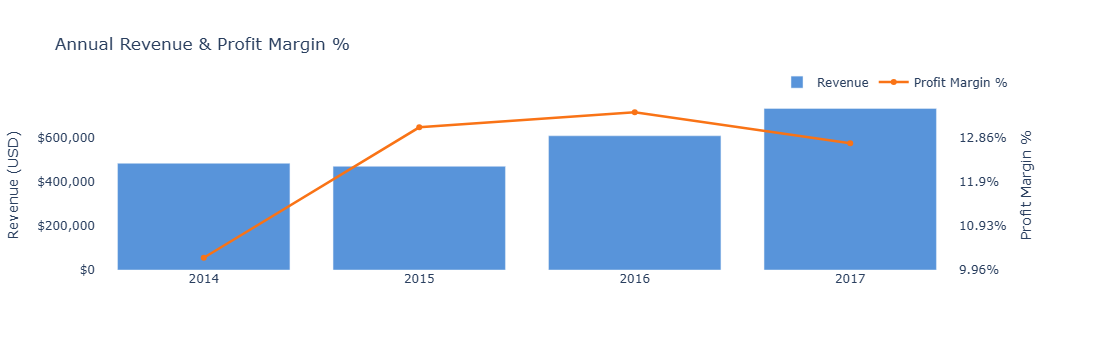

In [7]:
fig = make_subplots(specs=[[{'secondary_y': True}]])

fig.add_trace(
    go.Bar(x=yearly['Year'].astype(str), y=yearly['Revenue'],
           name='Revenue', marker_color='#3b82d4', opacity=0.85),
    secondary_y=False,
)
fig.add_trace(
    go.Scatter(x=yearly['Year'].astype(str), y=yearly['ProfitMarginPct'],
               name='Profit Margin %', mode='lines+markers',
               line=dict(color='#f97316', width=2.5)),
    secondary_y=True,
)
fig.update_layout(
    title_text='Annual Revenue & Profit Margin %',
    plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=350,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.update_yaxes(title_text='Revenue (USD)', secondary_y=False, tickprefix='$', tickformat=',.0f')
fig.update_yaxes(title_text='Profit Margin %', secondary_y=True, ticksuffix='%')
fig.show()

**Commentary:**  
Revenue has grown consistently from 2014 to 2017. The profit margin percentage has remained relatively stable, suggesting that cost structures have grown roughly in proportion with revenue. A divergence between revenue growth and margin improvement would indicate that revenue gains are not translating to proportional profit gains — this warrants monitoring.

---
## Section 5 — Category & Sub-Category Analysis

In [8]:
cat = (
    df.groupby('Category')
    .agg(Revenue=('Sales','sum'), Profit=('Profit','sum'))
    .reset_index()
)
cat['ProfitMarginPct'] = cat['Profit'] / cat['Revenue'] * 100
print(cat.round(2).to_string(index=False))

       Category   Revenue    Profit  ProfitMarginPct
      Furniture 741999.80  18451.27             2.49
Office Supplies 719047.03 122490.80            17.04
     Technology 836154.03 145454.95            17.40


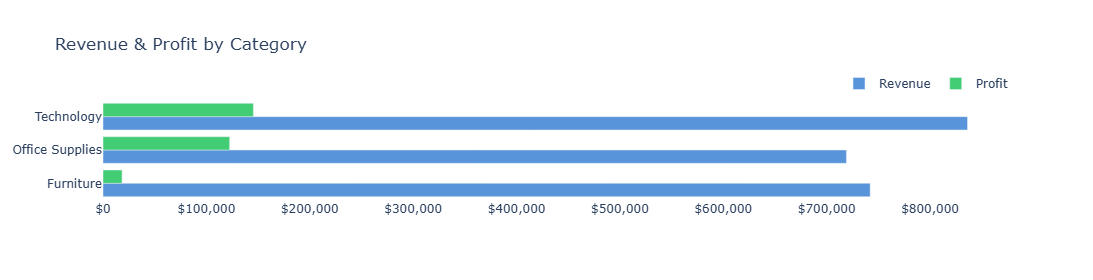

In [9]:
fig = go.Figure()
fig.add_trace(go.Bar(y=cat['Category'], x=cat['Revenue'], name='Revenue',
                     orientation='h', marker_color='#3b82d4', opacity=0.85))
fig.add_trace(go.Bar(y=cat['Category'], x=cat['Profit'], name='Profit',
                     orientation='h', marker_color='#22c55e', opacity=0.85))
fig.update_layout(
    title_text='Revenue & Profit by Category',
    barmode='group', plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=280,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.update_xaxes(tickprefix='$', tickformat=',.0f')
fig.show()

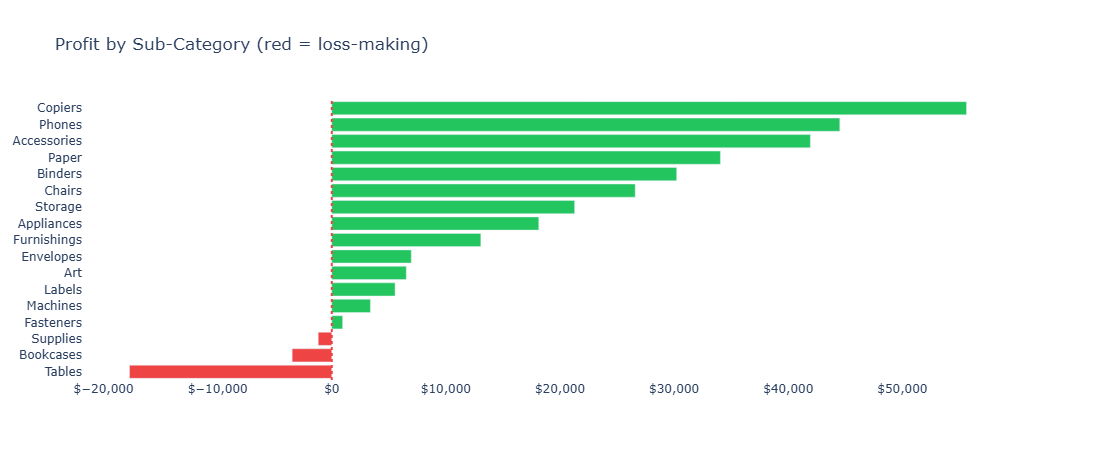


Loss-making sub-categories:
Sub-Category   Revenue    Profit  ProfitMarginPct
      Tables 206965.53 -17725.48            -8.56
   Bookcases 114880.00  -3472.56            -3.02
    Supplies  46673.54  -1189.10            -2.55


In [10]:
# Sub-category detail
subcat = (
    df.groupby('Sub-Category')
    .agg(Revenue=('Sales','sum'), Profit=('Profit','sum'))
    .reset_index()
    .sort_values('Profit')
)
subcat['ProfitMarginPct'] = subcat['Profit'] / subcat['Revenue'] * 100

colours = ['#ef4444' if v < 0 else '#22c55e' for v in subcat['Profit']]
fig = go.Figure(
    go.Bar(y=subcat['Sub-Category'], x=subcat['Profit'], orientation='h', marker_color=colours)
)
fig.add_vline(x=0, line_dash='dot', line_color='#ef4444')
fig.update_layout(
    title_text='Profit by Sub-Category (red = loss-making)',
    plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=460,
)
fig.update_xaxes(tickprefix='$', tickformat=',.0f')
fig.show()

print('\nLoss-making sub-categories:')
print(subcat[subcat['Profit']<0][['Sub-Category','Revenue','Profit','ProfitMarginPct']].round(2).to_string(index=False))

**Commentary:**  
Technology and Office Supplies both carry margins above 17%, while Furniture sits near 2.5% — far below the portfolio average. At the sub-category level, Tables, Bookcases, and Supplies show negative cumulative profit, representing structural loss areas that drag on overall performance.

---
## Section 6 — Regional Analysis

In [11]:
region = (
    df.groupby('Region')
    .agg(Revenue=('Sales','sum'), Profit=('Profit','sum'))
    .reset_index()
)
region['ProfitMarginPct'] = region['Profit'] / region['Revenue'] * 100
print(region.sort_values('ProfitMarginPct').round(2).to_string(index=False))

 Region   Revenue    Profit  ProfitMarginPct
Central 501239.89  39706.36             7.92
  South 391721.90  46749.43            11.93
   East 678781.24  91522.78            13.48
   West 725457.82 108418.45            14.94


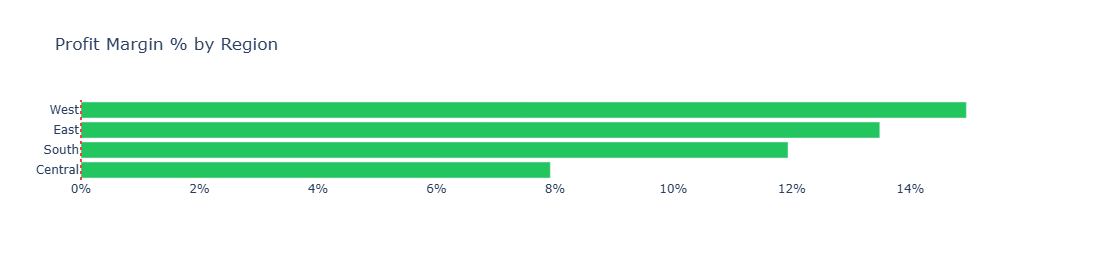

In [12]:
reg_sorted = region.sort_values('ProfitMarginPct')
colours = ['#22c55e' if v >= 0 else '#ef4444' for v in reg_sorted['ProfitMarginPct']]
fig = go.Figure(
    go.Bar(y=reg_sorted['Region'], x=reg_sorted['ProfitMarginPct'],
           orientation='h', marker_color=colours)
)
fig.add_vline(x=0, line_dash='dot', line_color='#ef4444')
fig.update_layout(
    title_text='Profit Margin % by Region',
    plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=260,
)
fig.update_xaxes(ticksuffix='%')
fig.show()

**Commentary:**  
All four regions are profitable, but the Central region carries the lowest margin. The West region leads in both absolute profit and margin percentage. Regional margin differences may reflect differences in product mix, discount usage, shipping costs, or customer segment distribution — further investigation at the order level is recommended before drawing causal conclusions.

---
## Section 7 — Product Analysis

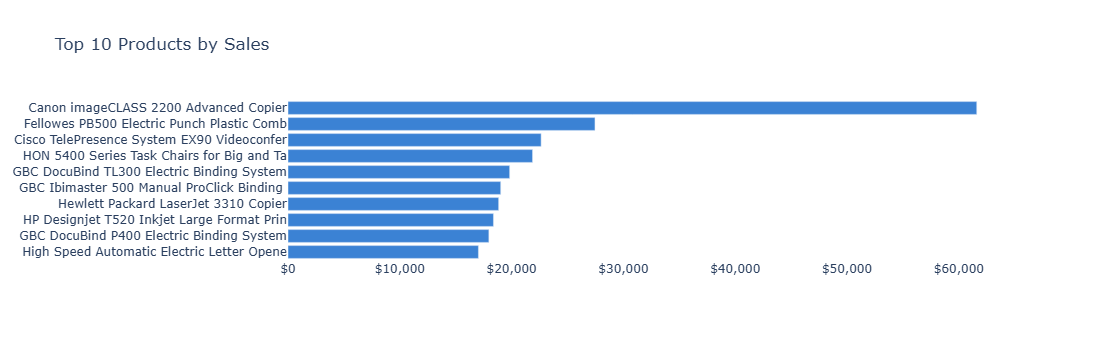

In [13]:
prod = (
    df.groupby('Product Name')
    .agg(Revenue=('Sales','sum'), Profit=('Profit','sum'))
    .reset_index()
)

top10_rev = prod.nlargest(10, 'Revenue').copy()
top10_rev['Label'] = top10_rev['Product Name'].str[:42]
top10_rev = top10_rev.sort_values('Revenue')

fig = go.Figure(
    go.Bar(y=top10_rev['Label'], x=top10_rev['Revenue'], orientation='h', marker_color='#3b82d4')
)
fig.update_layout(
    title_text='Top 10 Products by Sales',
    plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=340,
)
fig.update_xaxes(tickprefix='$', tickformat=',.0f')
fig.show()

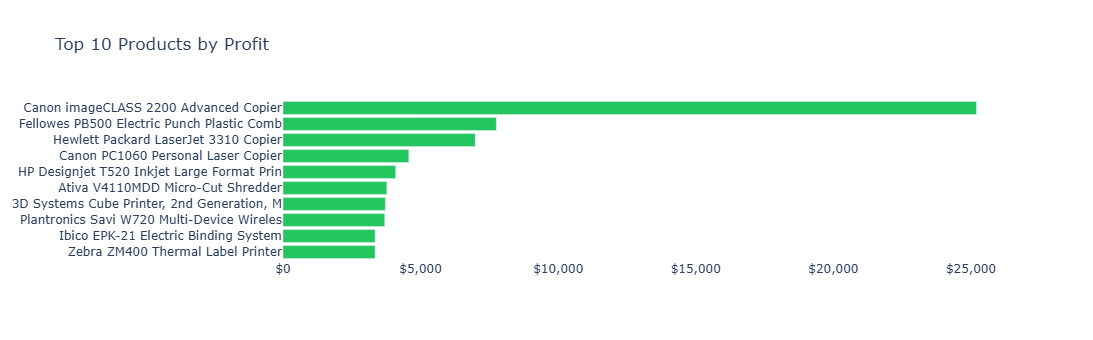

In [14]:
top10_prf = prod.nlargest(10, 'Profit').copy()
top10_prf['Label'] = top10_prf['Product Name'].str[:42]
top10_prf = top10_prf.sort_values('Profit')

fig = go.Figure(
    go.Bar(y=top10_prf['Label'], x=top10_prf['Profit'], orientation='h', marker_color='#22c55e')
)
fig.update_layout(
    title_text='Top 10 Products by Profit',
    plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=340,
)
fig.update_xaxes(tickprefix='$', tickformat=',.0f')
fig.show()

**Commentary:**  
The top products by sales revenue are not always the same as the top products by profit — this divergence highlights that high-revenue products may carry low or negative margins. High-volume products with thin margins deserve particular attention when setting pricing or discount policy.

---
## Section 8 — Customer & Segment Analysis

In [15]:
seg = (
    df.groupby('Segment')
    .agg(
        Revenue=('Sales','sum'),
        Profit=('Profit','sum'),
        Orders=('Order ID','nunique'),
        Customers=('Customer ID','nunique'),
    )
    .reset_index()
)
seg['ProfitMarginPct'] = seg['Profit'] / seg['Revenue'] * 100
print(seg.round(2).to_string(index=False))

    Segment    Revenue    Profit  Orders  Customers  ProfitMarginPct
   Consumer 1161401.34 134119.21    2586        409            11.55
  Corporate  706146.37  91979.13    1514        236            13.03
Home Office  429653.15  60298.68     909        148            14.03


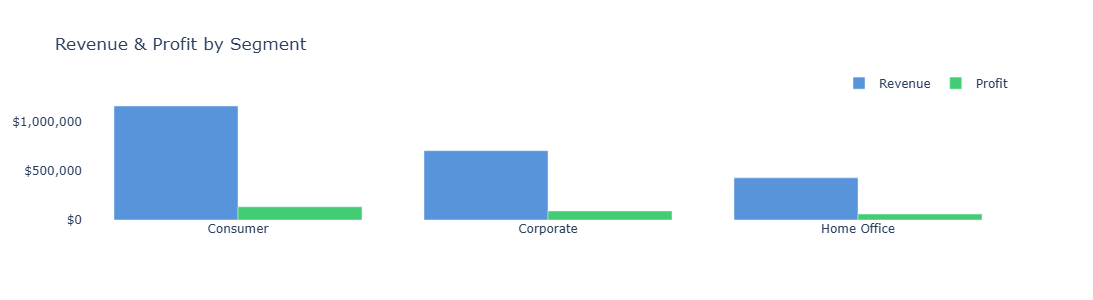

In [16]:
fig = go.Figure()
fig.add_trace(go.Bar(name='Revenue', x=seg['Segment'], y=seg['Revenue'],
                     marker_color='#3b82d4', opacity=0.85))
fig.add_trace(go.Bar(name='Profit',  x=seg['Segment'], y=seg['Profit'],
                     marker_color='#22c55e', opacity=0.85))
fig.update_layout(
    title_text='Revenue & Profit by Segment',
    barmode='group', plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=300,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.update_yaxes(tickprefix='$', tickformat=',.0f')
fig.show()

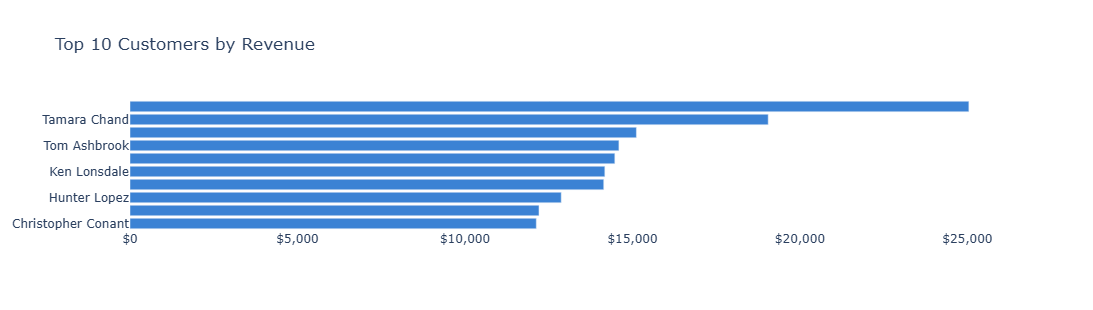

In [17]:
# Top 10 customers by revenue
top_cust = (
    df.groupby('Customer Name')['Sales'].sum()
    .nlargest(10).reset_index().sort_values('Sales')
)
fig = go.Figure(
    go.Bar(y=top_cust['Customer Name'], x=top_cust['Sales'],
           orientation='h', marker_color='#3b82d4')
)
fig.update_layout(
    title_text='Top 10 Customers by Revenue',
    plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=310,
)
fig.update_xaxes(tickprefix='$', tickformat=',.0f')
fig.show()

**Commentary:**  
Consumer is the largest segment by both revenue and order count, while Home Office has the highest profit margin percentage. This suggests that smaller, more targeted segments can be more efficient even with lower absolute volumes. Top-10 customers show notable revenue concentration — a few key accounts contribute disproportionately to revenue.

---
## Section 9 — Risk Analysis

In [18]:
# Loss-making sub-categories
loss = subcat[subcat['Profit'] < 0].sort_values('Profit')
print('Loss-making sub-categories:')
print(loss[['Sub-Category','Revenue','Profit','ProfitMarginPct']].round(2).to_string(index=False))

Loss-making sub-categories:
Sub-Category   Revenue    Profit  ProfitMarginPct
      Tables 206965.53 -17725.48            -8.56
   Bookcases 114880.00  -3472.56            -3.02
    Supplies  46673.54  -1189.10            -2.55


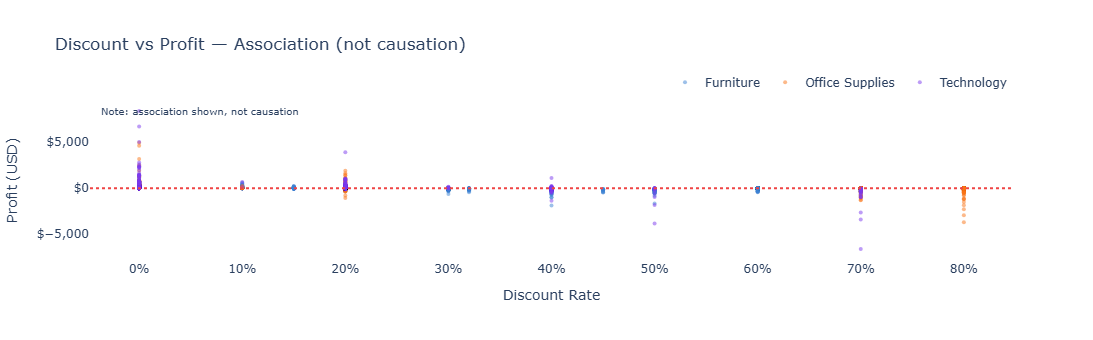

In [19]:
# Discount vs Profit scatter
fig = go.Figure()
cat_colours = {'Furniture': '#3b82d4', 'Office Supplies': '#f97316', 'Technology': '#7c3aed'}
for cat_name, colour in cat_colours.items():
    sub = df[df['Category'] == cat_name]
    fig.add_trace(
        go.Scatter(x=sub['Discount'], y=sub['Profit'], mode='markers', name=cat_name,
                   marker=dict(color=colour, size=4, opacity=0.5))
    )
fig.add_hline(y=0, line_dash='dot', line_color='#ef4444')
fig.update_layout(
    title_text='Discount vs Profit — Association (not causation)',
    annotations=[dict(
        text='Note: association shown, not causation',
        xref='paper', yref='paper', x=0.01, y=0.98,
        showarrow=False, font=dict(size=10), align='left',
    )],
    plot_bgcolor='#ffffff', paper_bgcolor='#ffffff', height=340,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
)
fig.update_xaxes(title_text='Discount Rate', tickformat='.0%')
fig.update_yaxes(title_text='Profit (USD)', tickprefix='$', tickformat=',.0f')
fig.show()

In [20]:
# Average profit by discount band
high = df[df['Discount'] >= 0.3]['Profit'].mean()
low  = df[df['Discount'] <  0.3]['Profit'].mean()
print(f'Avg profit (discount >= 30%): ${high:,.2f}')
print(f'Avg profit (discount <  30%): ${low:,.2f}')
print('Note: This is an association. Causal interpretation requires further analysis.')

Avg profit (discount >= 30%): $-97.18
Avg profit (discount <  30%): $49.04
Note: This is an association. Causal interpretation requires further analysis.


**Commentary:**  
The scatter chart shows that higher discount rates are associated with lower or negative profit per transaction. This association is visible across all categories but is most pronounced for Furniture. However, correlation does not imply causation — other variables (product cost, order size, returns) may also contribute. A controlled analysis would be required to establish causal direction.

---
## Section 10 — Findings Summary

All values below are computed directly from the dataset.

| Label | Finding |
|---|---|
| **FACT** | 9,994 transactions, 5,009 unique orders, 793 unique customers, Jan 2014 – Dec 2017 |
| **FACT** | Total revenue: $2,297,200.86 \| Total profit: $286,397.02 \| Overall margin: 12.47% |
| **FACT** | Three categories: Furniture (2.5% margin), Office Supplies (17.0%), Technology (17.4%) |
| **FACT** | Three loss-making sub-categories: Tables, Bookcases, Supplies |
| **INSIGHT** | Technology and Office Supplies are the margin leaders; Furniture lags significantly |
| **INSIGHT** | Revenue has grown year-over-year from 2014 to 2017; profit margin has remained stable |
| **INSIGHT** | West region leads in margin (14.9%); Central is lowest (7.9%) |
| **INSIGHT** | Home Office has the highest profit margin (14.0%) despite being the smallest segment |
| **RISK** | Tables sub-category has negative cumulative profit of -$17,725 |
| **RISK** | ~300 loss-making order lines; many are associated with high discount rates (≥30%) |
| **RISK** | Central region margin is 6 percentage points below the West region |
| **OPPORTUNITY** | Scaling Technology and Office Supplies (both >17% margin) could lift portfolio returns |
| **OPPORTUNITY** | Home Office segment is small but efficient — targeted growth may be high-value |
| **ACTION** | Audit pricing and discount policy for Tables, Bookcases, and Supplies sub-categories |
| **ACTION** | Review Central region's product mix and discount usage |
| **ACTION** | Investigate whether Furniture losses are structural or driven by discounting policy |

> **Limitation:** All associations between variables (e.g., discount and profit) are observational. This analysis does not establish causation. Business decisions should be validated with additional operational data before implementation.